# 2. Writing to Zarr

**Learning objectives**

By the end of this notebook you will be able to:

- Explain why Zarr is better than GRIB for ML training
- Convert an earthkit GRIB dataset to a Zarr store
- Open a Zarr store with xarray and inspect its structure
- Verify round-trip fidelity by comparing original and reloaded data
- Compare storage sizes between GRIB and Zarr

---

## Why Zarr for ML?

GRIB is the standard archival format for weather data. It was designed for transmission and long-term storage — **not** for the random-access read patterns of training loops.

Zarr is a chunked, compressed, cloud-native array format designed for exactly this:

| Property | GRIB | Zarr |
|---|---|---|
| Layout | Sequential messages | Chunked N-D arrays |
| Random access | Slow (scan whole file) | Fast (read one chunk) |
| Cloud-native | No | Yes (S3, GCS, ADLS) |
| Lazy loading | No | Yes |
| Parallel reads | No | Yes |
| Framework integration | Custom parsers | xarray, PyTorch, TF |

A DataLoader reading one timestep at a time from a time-chunked Zarr store reads exactly one chunk per sample — no wasted I/O.

## Setup

In [1]:
import earthkit.data as ekd
import xarray as xr
import zarr
import numpy as np
import os

ekd.settings.set({"cache-policy": "user"})
os.makedirs("data", exist_ok=True)

print("zarr version:", zarr.__version__)
print("xarray version:", xr.__version__)

zarr version: 3.1.6
xarray version: 2026.2.0


## Load ERA5 data

We load the same sample data as notebook 1 and also save a local copy of the GRIB file for size comparison.

In [ ]:
# DATA: era5-2t-msl-1985122512.grib — 2t and msl, single timestep

ds = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
print(f"FieldList: {len(ds)} field(s)")
ds.ls()

FieldList: 2 field(s)


,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2020-01-01 12:00:00,2020-01-01 12:00:00,0 days,0,surface,0,reduced_gg
1,msl,2020-01-01 12:00:00,2020-01-01 12:00:00,0 days,0,surface,0,reduced_gg


In [26]:
# Save the GRIB for size comparison
grib_path = "data/era5_sample.grib"
ds.to_target('file', grib_path)
print(f"GRIB saved: {grib_path}")


GRIB saved: data/era5_sample.grib


## Convert to Zarr

earthkit-data provides a `to_target()` method that handles the GRIB → xarray → Zarr conversion in one call. Under the hood it:

1. Decodes GRIB metadata and values
2. Builds a CF-convention xarray Dataset
3. Encodes and writes to the Zarr format

In [30]:
zarr_path = "data/era5.zarr"

ds.to_target(
    "zarr",
    xarray_to_zarr_kwargs={"store": zarr_path, "mode": "w"},
)

print(f"Zarr store written to: {zarr_path}")

Zarr store written to: data/era5.zarr


Alternatively you can go via xarray directly, which gives you full control over encoding:

In [31]:
# Alternative route: earthkit -> xarray -> zarr
# xr_ds = ds.to_xarray()
# xr_ds.to_zarr(zarr_path, mode="w")

## Inspect the Zarr store

A Zarr store is a directory of small binary files — one per chunk, plus metadata. Let's look inside.

In [32]:
# Open with the zarr library to inspect the raw structure
store = zarr.open(zarr_path, mode="r")
print(store.tree())

/
├── 2t (542080,) float64
├── latitude (542080,) float64
├── longitude (542080,) float64
└── msl (542080,) float64



In [33]:
# Open with xarray — this is how downstream code will use it
zarr_ds = xr.open_dataset(zarr_path, engine="zarr")
print(zarr_ds)

<xarray.Dataset> Size: 17MB
Dimensions:    (values: 542080)
Coordinates:
    latitude   (values) float64 4MB ...
    longitude  (values) float64 4MB ...
Dimensions without coordinates: values
Data variables:
    2t         (values) float64 4MB ...
    msl        (values) float64 4MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF


In [34]:
# Inspect chunk layout
for var in zarr_ds.data_vars:
    encoding = zarr_ds[var].encoding
    print(f"{var}: chunks={encoding.get('chunks')}, dtype={zarr_ds[var].dtype}")

2t: chunks=(67760,), dtype=float64
msl: chunks=(67760,), dtype=float64


## Round-trip verification

Confirm that the values stored in Zarr match the original GRIB data.

In [35]:
original = ds.to_xarray()

for var in original.data_vars:
    orig_vals = original[var].values
    zarr_vals = zarr_ds[var].values
    max_diff = np.abs(orig_vals - zarr_vals).max()
    print(f"{var}: max absolute difference = {max_diff:.6f}")

2t: max absolute difference = 0.000000
msl: max absolute difference = 0.000000


## Visualise from Zarr

Plotting directly from the Zarr store confirms the data is intact.

Read  rate: 317.25 Kbytes per second
Write rate: 2.82197 Gbytes per second
Save into: 45 seconds elapsed, 1 second cpu
Download of 13.8041 Mbytes took 45.9556s.


6af4372d8f5d8ed3e40a56a45aa026f224ff9c503761d68ab6775ae90501d5cd.npz:   0%|          | 0.00/20.2M [00:00<?, ?B…

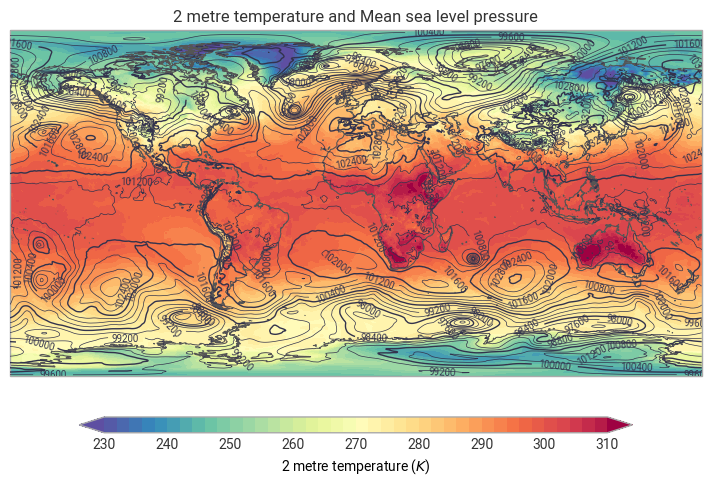

In [36]:
import earthkit.plots as ekp

# Visualise from the Zarr store (via xarray) — confirms round-trip fidelity
ekp.quickplot(zarr_ds, mode = 'overlay');


## File size comparison

In [37]:
def directory_size_kb(path):
    """Total size of a directory tree in kilobytes."""
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / 1024

grib_kb = os.path.getsize(grib_path) / 1024
zarr_kb = directory_size_kb(zarr_path)

print(f"GRIB size : {grib_kb:.1f} KB")
print(f"Zarr size : {zarr_kb:.1f} KB")
print(f"Ratio     : {zarr_kb / grib_kb:.2f}x")

GRIB size : 2120.2 KB
Zarr size : 2484.6 KB
Ratio     : 1.17x


> **Note on compression**
>
> Zarr uses chunk-level compression (Blosc by default). For small test files the overhead from metadata files can make Zarr appear larger. At real ERA5 scales (gigabytes to terabytes) Zarr is typically more compact than GRIB and dramatically faster for random access.

---

## Summary

You have:

- Converted a GRIB file to a Zarr store at `data/era5.zarr`
- Verified the round-trip is lossless
- Confirmed the Zarr store can be opened with xarray and earthkit.plots

This Zarr store is the input for all subsequent notebooks.

---

> **Activity**
>
> 1. Re-run the `to_target()` call with an explicit chunk size: add `earthkit_to_xarray_kwargs={"chunks": {"latitude": 5, "longitude": 5}}` and inspect the new chunk layout with `store.tree()`.
> 2. What happens to the Zarr directory structure when you change chunk sizes?
> 3. How does the file count in the Zarr directory relate to the number of chunks?
>
> ```python
> # Your code here
> ```